# GBM_SEEP

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb

## Importing the dataset

In [ ]:
dataset = pd.read_csv('globalbrgdgtlabel.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
dataset2 = pd.read_csv('CP.csv')
X_CP = dataset2.iloc[:, :-1].values
depth_CP = dataset2.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from imblearn.over_sampling import SMOTE
# transform the dataset
oversample = SMOTE(random_state=11)
X_train, y_train = oversample.fit_resample(X_train, y_train)

## Training LGBMClassifier on the Training set

In [ ]:
from lightgbm import LGBMClassifier
classifier = LGBMClassifier()
classifier.fit(X_train, y_train)

LGBMClassifier()

## Making the Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[117   0   0]
 [  0   5   0]
 [  2   0  60]]


0.9891304347826086

In [ ]:
print(classifier.predict_proba(X_test))

dct=classifier.predict_proba(X_test)
df1 = pd.DataFrame(dct) 
df1.to_csv('probability.csv')

[[2.96248689e-05 2.45136748e-05 9.99945861e-01]
 [1.75435858e-05 2.02454077e-05 9.99962211e-01]
 [3.12151959e-05 9.99947071e-01 2.17135112e-05]
 [9.99803868e-01 1.19961405e-04 7.61708094e-05]
 [9.84899537e-01 1.34316647e-02 1.66879786e-03]
 [9.99846338e-01 1.02237489e-04 5.14243237e-05]
 [2.82321440e-05 2.27366461e-05 9.99949031e-01]
 [9.96718053e-01 3.18201569e-03 9.99309210e-05]
 [9.99869448e-01 1.82624855e-05 1.12289200e-04]
 [9.99562385e-01 3.82201833e-04 5.54127920e-05]
 [9.99001933e-01 9.80896988e-04 1.71701366e-05]
 [9.99938161e-01 3.01340258e-05 3.17049146e-05]
 [2.10559987e-05 2.24492217e-05 9.99956495e-01]
 [2.06043069e-05 2.04171271e-05 9.99958979e-01]
 [2.43528262e-05 2.24465846e-05 9.99953201e-01]
 [3.56009589e-05 3.00544490e-05 9.99934345e-01]
 [9.99964477e-01 1.71611993e-05 1.83616659e-05]
 [9.99960593e-01 1.85957481e-05 2.08109212e-05]
 [9.99633248e-01 2.15682222e-04 1.51069533e-04]
 [1.70622621e-05 1.43651095e-05 9.99968573e-01]
 [9.99859293e-01 1.80581177e-05 1.226493

## Applying k-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 99.60 %
Standard Deviation: 0.66 %


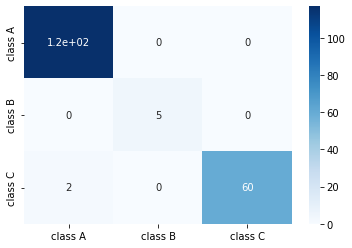

In [ ]:
from string import ascii_uppercase
from pandas import DataFrame
import numpy as np
import seaborn as sn
from sklearn.metrics import confusion_matrix

columns = ['class %s' %(i) for i in list(ascii_uppercase)[0:len(np.unique(y_test))]]

confm = confusion_matrix(y_test, y_pred)
df_cm = DataFrame(confm, index=columns, columns=columns)

ax = sn.heatmap(df_cm, cmap='Blues', annot=True)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       117
           1       1.00      1.00      1.00         5
           2       1.00      0.97      0.98        62

    accuracy                           0.99       184
   macro avg       0.99      0.99      0.99       184
weighted avg       0.99      0.99      0.99       184



In [ ]:
pip install shap

     |████████████████████████████████| 564 kB 11.5 MB/s 


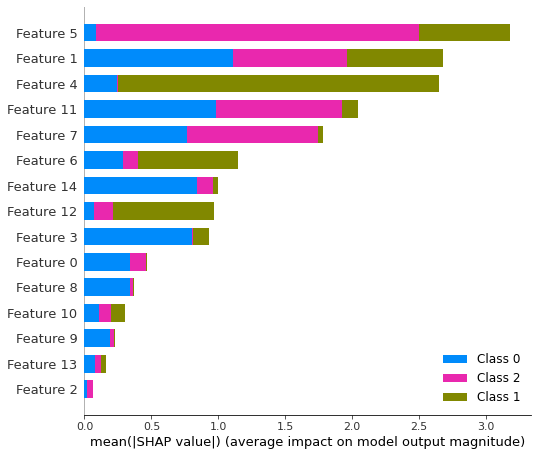

In [ ]:
import shap
shap_values = shap.TreeExplainer(classifier).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar",show=False)
plt.savefig("SHAP_bar.pdf", format='pdf', dpi=1000, bbox_inches='tight')



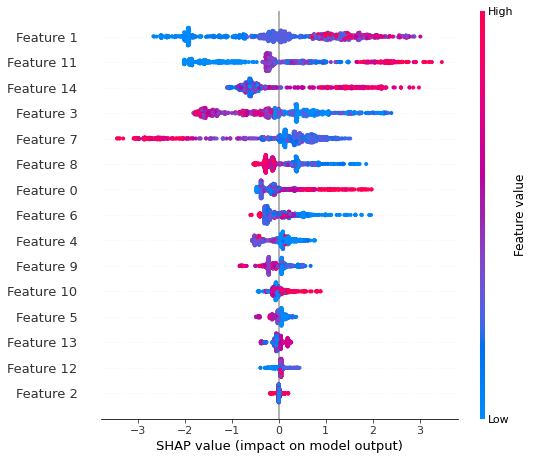

In [ ]:
shap.summary_plot(shap_values[0], X_train, show=False)
plt.savefig("class0.pdf", format='pdf', dpi=1000, bbox_inches='tight')

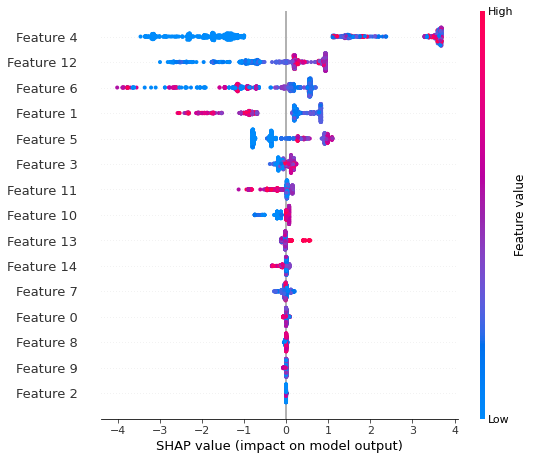

In [ ]:
shap.summary_plot(shap_values[1], X_train, show=False)
plt.savefig("class1.pdf", format='pdf', dpi=1000, bbox_inches='tight')

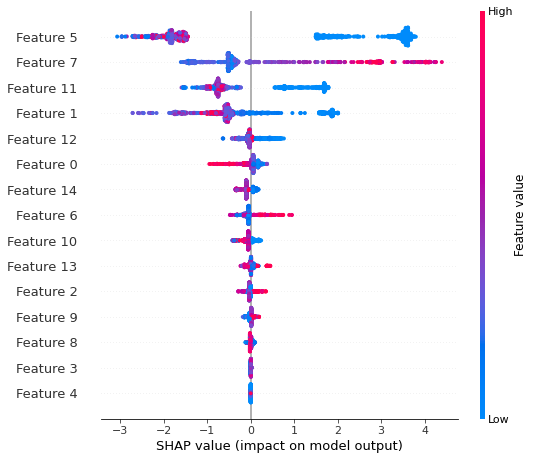

In [ ]:
shap.summary_plot(shap_values[2], X_train, show=False)
plt.savefig("class2.pdf", format='pdf', dpi=1000, bbox_inches='tight')

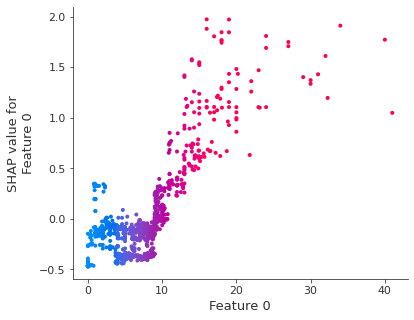

In [ ]:
shap.dependence_plot("Feature 0", shap_values[0], X_train, interaction_index = 0, show=False)
plt.savefig("00.pdf", format='pdf', dpi=1000, bbox_inches='tight')

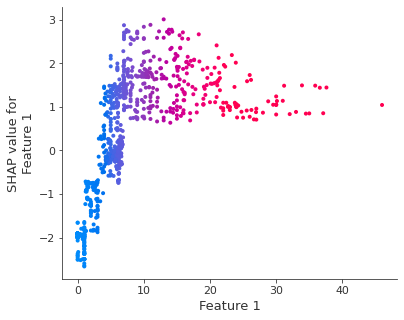

In [ ]:
shap.dependence_plot("Feature 1", shap_values[0], X_train, interaction_index = 1, show=False)
plt.savefig("10.pdf", format='pdf', dpi=1000, bbox_inches='tight')

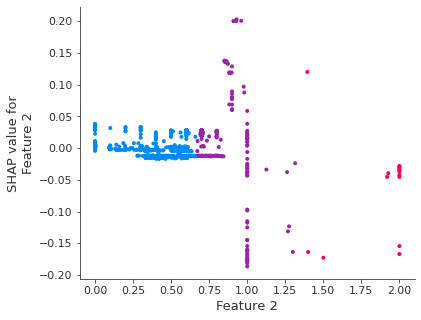

In [ ]:
shap.dependence_plot("Feature 2", shap_values[0], X_train, interaction_index = 2, show=False)
plt.savefig("20.pdf", format='pdf', dpi=1000, bbox_inches='tight')

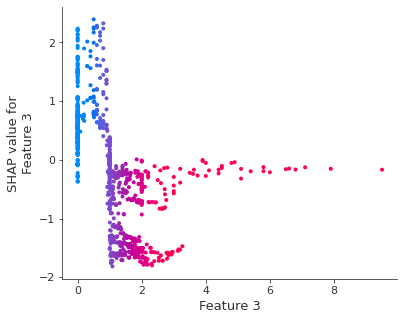

In [ ]:
shap.dependence_plot("Feature 3", shap_values[0], X_train, interaction_index = 3, show=False)
plt.savefig("30.pdf", format='pdf', dpi=1000, bbox_inches='tight')

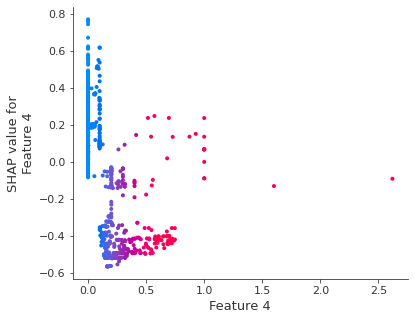

In [ ]:
shap.dependence_plot("Feature 4", shap_values[0], X_train, interaction_index = 4, show=False)
plt.savefig("40.pdf", format='pdf', dpi=1000, bbox_inches='tight')

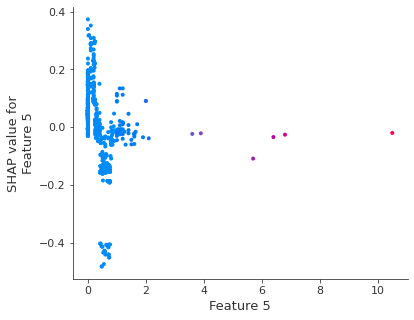

In [ ]:
shap.dependence_plot("Feature 5", shap_values[0], X_train, interaction_index = 5, show=False)
plt.savefig("50.pdf", format='pdf', dpi=1000, bbox_inches='tight')

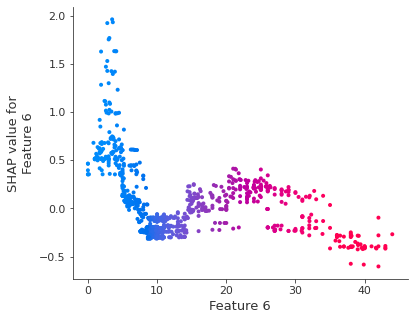

In [ ]:
shap.dependence_plot("Feature 6", shap_values[0], X_train, interaction_index = 6, show=False)
plt.savefig("60.pdf", format='pdf', dpi=1000, bbox_inches='tight')

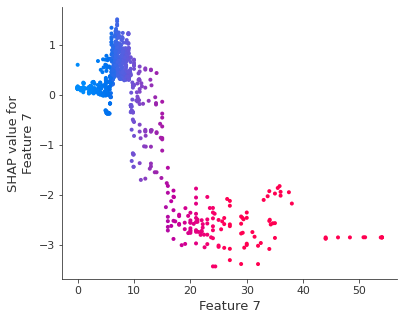

In [ ]:
shap.dependence_plot("Feature 7", shap_values[0], X_train, interaction_index = 7, show=False)
plt.savefig("70.pdf", format='pdf', dpi=1000, bbox_inches='tight')

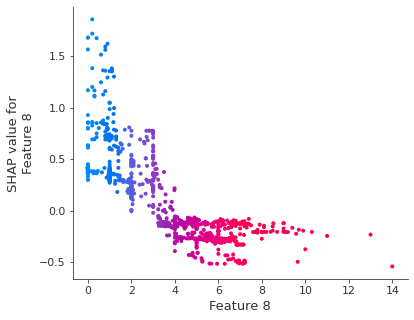

In [ ]:
shap.dependence_plot("Feature 8", shap_values[0], X_train, interaction_index = 8, show=False)
plt.savefig("80.pdf", format='pdf', dpi=1000, bbox_inches='tight')

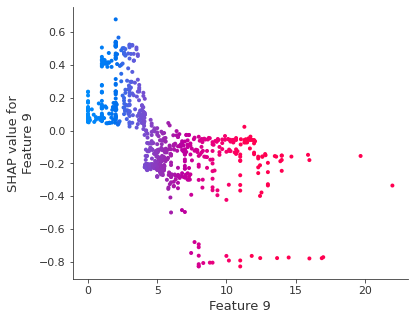

In [ ]:
shap.dependence_plot("Feature 9", shap_values[0], X_train, interaction_index = 9, show=False)
plt.savefig("90.pdf", format='pdf', dpi=1000, bbox_inches='tight')

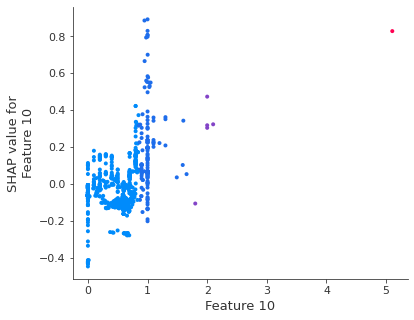

In [ ]:
shap.dependence_plot("Feature 10", shap_values[0], X_train, interaction_index = 10, show=False)
plt.savefig("100.pdf", format='pdf', dpi=1000, bbox_inches='tight')

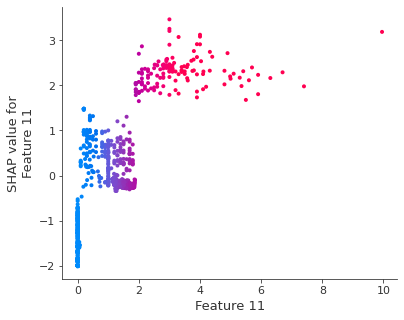

In [ ]:
shap.dependence_plot("Feature 11", shap_values[0], X_train, interaction_index = 11, show=False)
plt.savefig("110.pdf", format='pdf', dpi=1000, bbox_inches='tight')

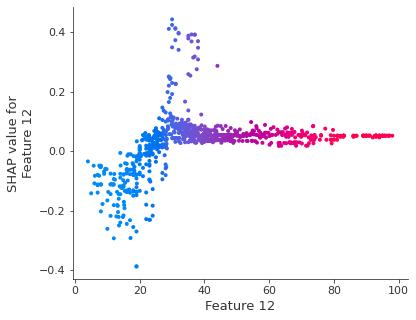

In [ ]:
shap.dependence_plot("Feature 12", shap_values[0], X_train, interaction_index = 12, show=False)
plt.savefig("120.pdf", format='pdf', dpi=1000, bbox_inches='tight')

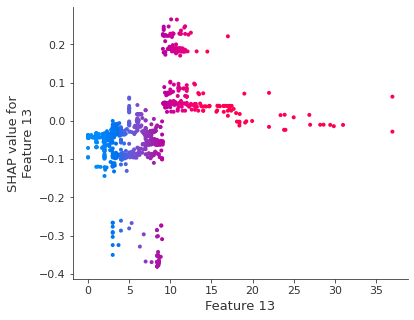

In [ ]:
shap.dependence_plot("Feature 13", shap_values[0], X_train, interaction_index = 13, show=False)
plt.savefig("130.pdf", format='pdf', dpi=1000, bbox_inches='tight')

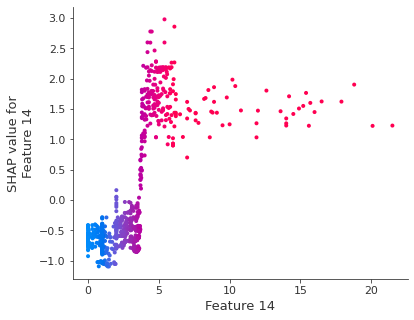

In [ ]:
shap.dependence_plot("Feature 14", shap_values[0], X_train, interaction_index = 14, show=False)
plt.savefig("140.pdf", format='pdf', dpi=1000, bbox_inches='tight')

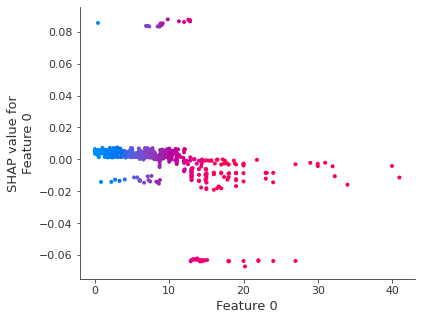

In [ ]:
shap.dependence_plot("Feature 0", shap_values[1], X_train, interaction_index = 0, show=False)
plt.savefig("01.pdf", format='pdf', dpi=1000, bbox_inches='tight')

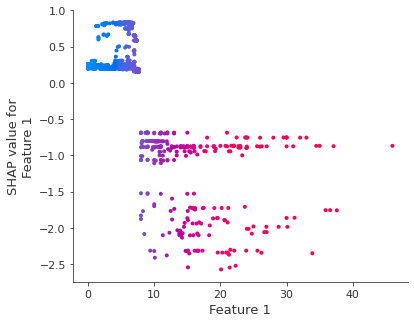

In [ ]:
shap.dependence_plot("Feature 1", shap_values[1], X_train, interaction_index = 1, show=False)
plt.savefig("11.pdf", format='pdf', dpi=1000, bbox_inches='tight')

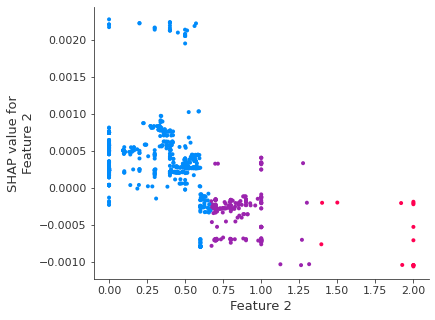

In [ ]:
shap.dependence_plot("Feature 2", shap_values[1], X_train, interaction_index = 2, show=False)
plt.savefig("21.pdf", format='pdf', dpi=1000, bbox_inches='tight')

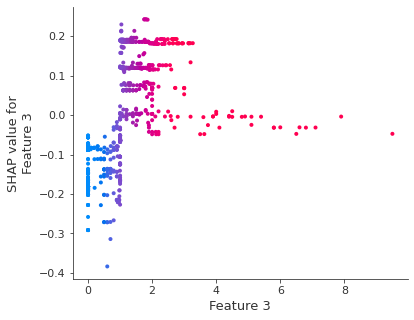

In [ ]:
shap.dependence_plot("Feature 3", shap_values[1], X_train, interaction_index = 3, show=False)
plt.savefig("31.pdf", format='pdf', dpi=1000, bbox_inches='tight')

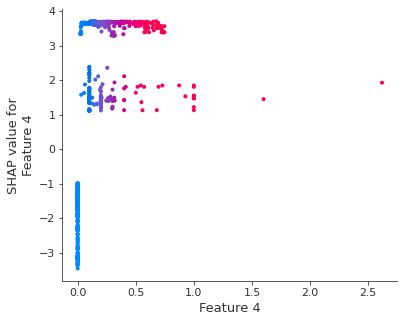

In [ ]:
shap.dependence_plot("Feature 4", shap_values[1], X_train, interaction_index = 4, show=False)
plt.savefig("41.pdf", format='pdf', dpi=1000, bbox_inches='tight')

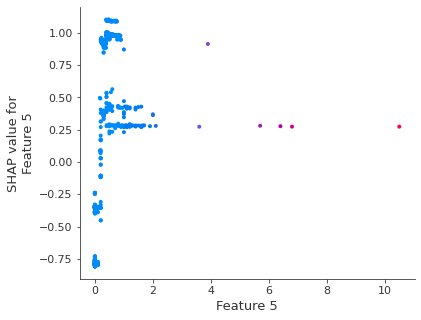

In [ ]:
shap.dependence_plot("Feature 5", shap_values[1], X_train, interaction_index = 5, show=False)
plt.savefig("51.pdf", format='pdf', dpi=1000, bbox_inches='tight')

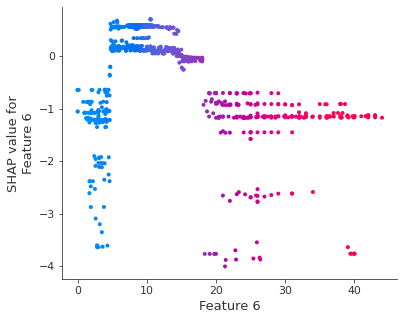

In [ ]:
shap.dependence_plot("Feature 6", shap_values[1], X_train, interaction_index = 6, show=False)
plt.savefig("61.pdf", format='pdf', dpi=1000, bbox_inches='tight')

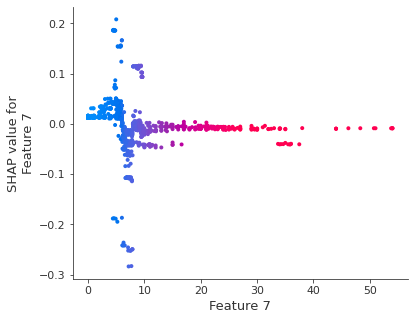

In [ ]:
shap.dependence_plot("Feature 7", shap_values[1], X_train, interaction_index = 7, show=False)
plt.savefig("71.pdf", format='pdf', dpi=1000, bbox_inches='tight')

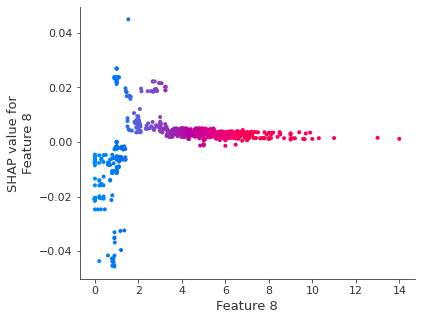

In [ ]:
shap.dependence_plot("Feature 8", shap_values[1], X_train, interaction_index = 8, show=False)
plt.savefig("81.pdf", format='pdf', dpi=1000, bbox_inches='tight')

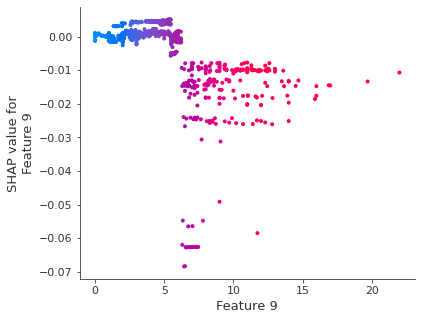

In [ ]:
shap.dependence_plot("Feature 9", shap_values[1], X_train, interaction_index = 9, show=False)
plt.savefig("91.pdf", format='pdf', dpi=1000, bbox_inches='tight')

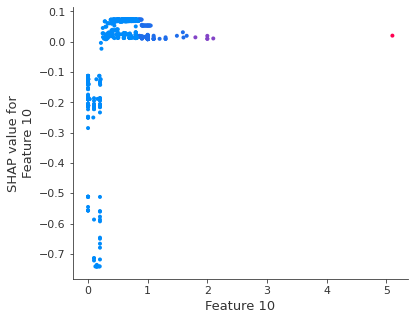

In [ ]:
shap.dependence_plot("Feature 10", shap_values[1], X_train, interaction_index = 10, show=False)
plt.savefig("101.pdf", format='pdf', dpi=1000, bbox_inches='tight')

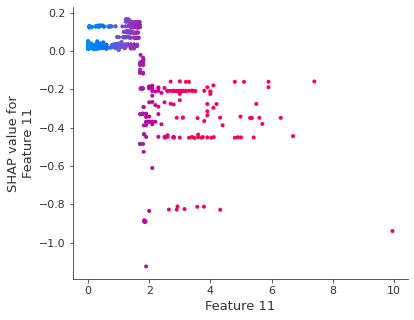

In [ ]:
shap.dependence_plot("Feature 11", shap_values[1], X_train, interaction_index = 11, show=False)
plt.savefig("111.pdf", format='pdf', dpi=1000, bbox_inches='tight')

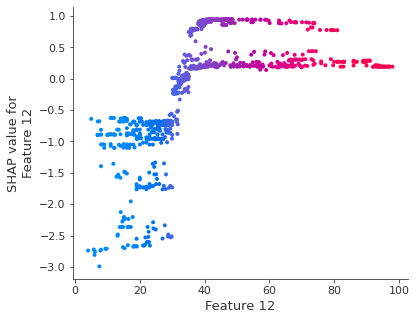

In [ ]:
shap.dependence_plot("Feature 12", shap_values[1], X_train, interaction_index = 12, show=False)
plt.savefig("121.pdf", format='pdf', dpi=1000, bbox_inches='tight')

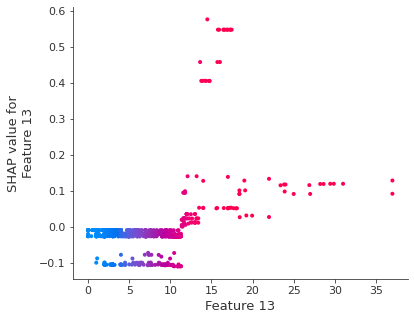

In [ ]:
shap.dependence_plot("Feature 13", shap_values[1], X_train, interaction_index = 13, show=False)
plt.savefig("131.pdf", format='pdf', dpi=1000, bbox_inches='tight')

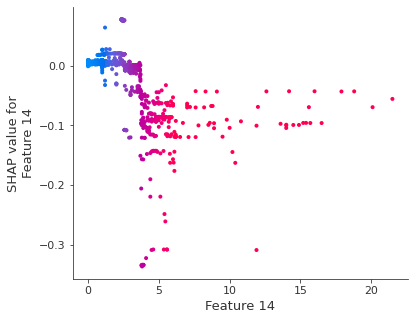

In [ ]:
shap.dependence_plot("Feature 14", shap_values[1], X_train, interaction_index = 14, show=False)
plt.savefig("141.pdf", format='pdf', dpi=1000, bbox_inches='tight')

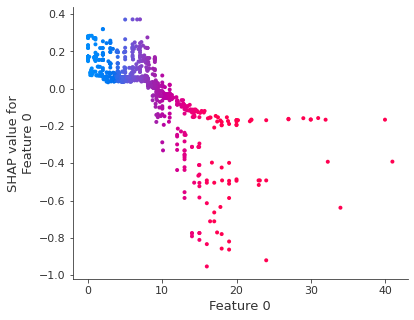

In [ ]:
shap.dependence_plot("Feature 0", shap_values[2], X_train, interaction_index = 0, show=False)
plt.savefig("02.pdf", format='pdf', dpi=1000, bbox_inches='tight')

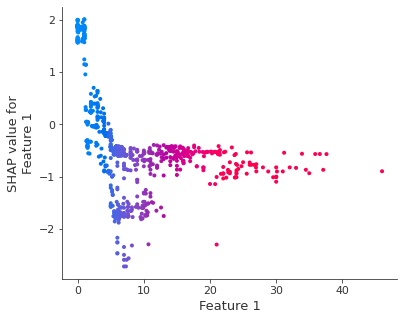

In [ ]:
shap.dependence_plot("Feature 1", shap_values[2], X_train, interaction_index = 1, show=False)
plt.savefig("12.pdf", format='pdf', dpi=1000, bbox_inches='tight')

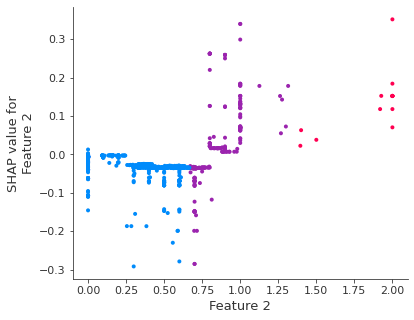

In [ ]:
shap.dependence_plot("Feature 2", shap_values[2], X_train, interaction_index = 2, show=False)
plt.savefig("22.pdf", format='pdf', dpi=1000, bbox_inches='tight')

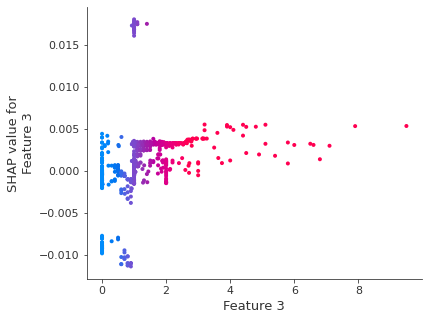

In [ ]:
shap.dependence_plot("Feature 3", shap_values[2], X_train, interaction_index = 3, show=False)
plt.savefig("32.pdf", format='pdf', dpi=1000, bbox_inches='tight')

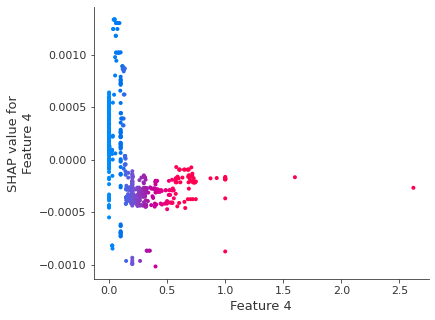

In [ ]:
shap.dependence_plot("Feature 4", shap_values[2], X_train, interaction_index = 4, show=False)
plt.savefig("42.pdf", format='pdf', dpi=1000, bbox_inches='tight')

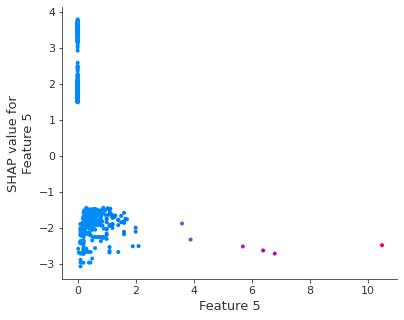

In [ ]:
shap.dependence_plot("Feature 5", shap_values[2], X_train, interaction_index = 5, show=False)
plt.savefig("52.pdf", format='pdf', dpi=1000, bbox_inches='tight')

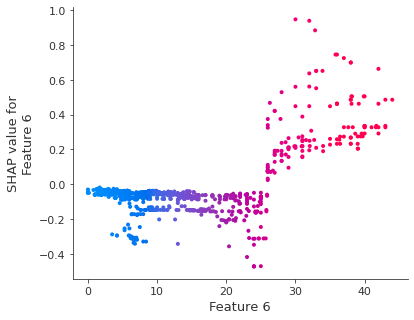

In [ ]:
shap.dependence_plot("Feature 6", shap_values[2], X_train, interaction_index = 6, show=False)
plt.savefig("62.pdf", format='pdf', dpi=1000, bbox_inches='tight')

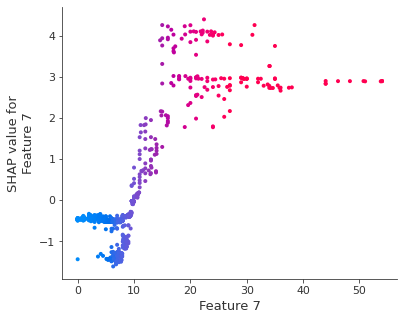

In [ ]:
shap.dependence_plot("Feature 7", shap_values[2], X_train, interaction_index = 7, show=False)
plt.savefig("72.pdf", format='pdf', dpi=1000, bbox_inches='tight')

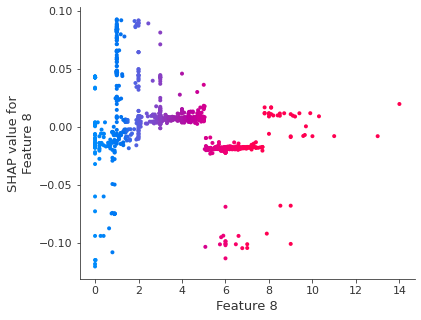

In [ ]:
shap.dependence_plot("Feature 8", shap_values[2], X_train, interaction_index = 8, show=False)
plt.savefig("82.pdf", format='pdf', dpi=1000, bbox_inches='tight')

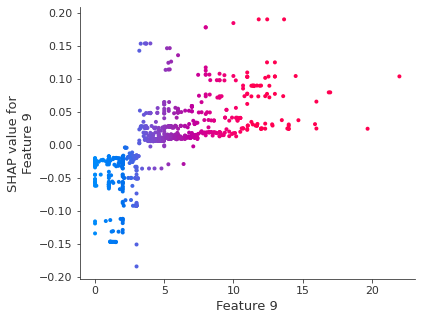

In [ ]:
shap.dependence_plot("Feature 9", shap_values[2], X_train, interaction_index = 9, show=False)
plt.savefig("92.pdf", format='pdf', dpi=1000, bbox_inches='tight')

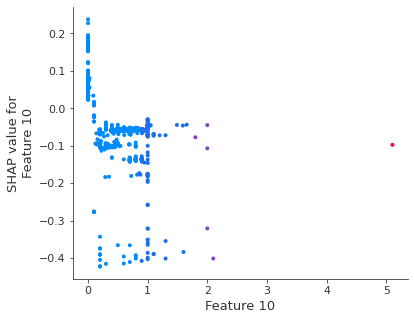

In [ ]:
shap.dependence_plot("Feature 10", shap_values[2], X_train, interaction_index = 10, show=False)
plt.savefig("102.pdf", format='pdf', dpi=1000, bbox_inches='tight')

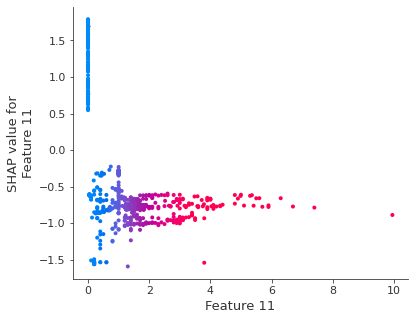

In [ ]:
shap.dependence_plot("Feature 11", shap_values[2], X_train, interaction_index = 11, show=False)
plt.savefig("112.pdf", format='pdf', dpi=1000, bbox_inches='tight')

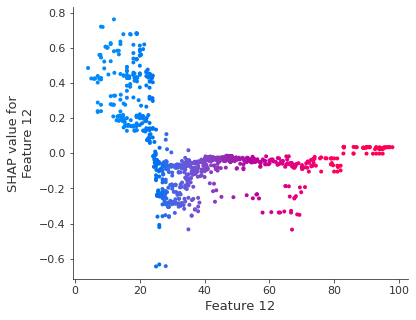

In [ ]:
shap.dependence_plot("Feature 12", shap_values[2], X_train, interaction_index = 12, show=False)
plt.savefig("122.pdf", format='pdf', dpi=1000, bbox_inches='tight')

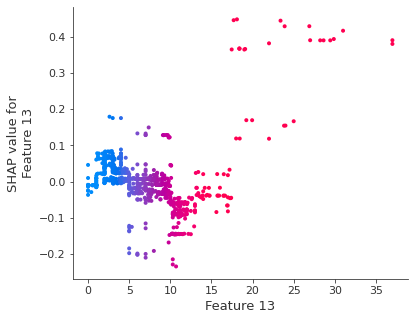

In [ ]:
shap.dependence_plot("Feature 13", shap_values[2], X_train, interaction_index = 13, show=False)
plt.savefig("132.pdf", format='pdf', dpi=1000, bbox_inches='tight')

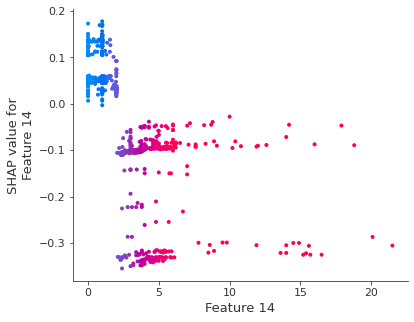

In [ ]:
shap.dependence_plot("Feature 14", shap_values[2], X_train, interaction_index = 14, show=False)
plt.savefig("142.pdf", format='pdf', dpi=1000, bbox_inches='tight')

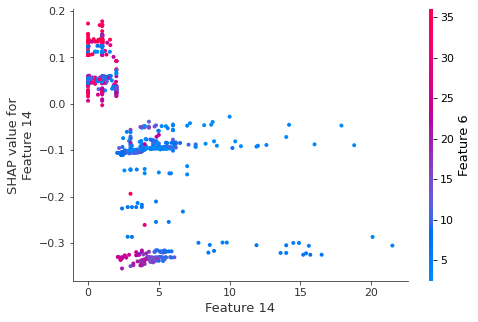

In [ ]:
shap.dependence_plot("Feature 14", shap_values[2], X_train, interaction_index = 6, show=False)
plt.savefig("label.pdf", format='pdf', dpi=1000, bbox_inches='tight')

# PETM_application

In [ ]:
y_predCP = classifier.predict(X_CP)
print(y_predCP)

[2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 0 2 2 2
 2 2 2 2 0 0 0 2 0 0 2 2 2 1 2 2 2 0 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 0 2 0 2 2]


In [ ]:
print(classifier.predict_proba(X_CP))

dct=classifier.predict_proba(X_CP)
df2 = pd.DataFrame(dct) 
df2.to_csv('probability.csv')

[[3.78296115e-01 4.07649937e-03 6.17627386e-01]
 [1.31693498e-02 2.75034692e-03 9.84080303e-01]
 [1.39932890e-01 1.39585247e-03 8.58671258e-01]
 [4.30791922e-01 3.74904047e-03 5.65459038e-01]
 [1.73184505e-02 3.22412394e-03 9.79457426e-01]
 [5.17333018e-03 1.08133460e-03 9.93745335e-01]
 [2.35869569e-01 2.77343375e-03 7.61356998e-01]
 [3.61256715e-01 1.08565973e-03 6.37657626e-01]
 [6.44912787e-03 1.37729832e-03 9.92173574e-01]
 [3.73531820e-01 4.40271891e-03 6.22065461e-01]
 [6.02694143e-03 1.37847638e-03 9.92594582e-01]
 [1.54980023e-02 3.54319425e-03 9.80958803e-01]
 [9.77605516e-01 5.68703141e-03 1.67074530e-02]
 [1.31693644e-02 2.74924394e-03 9.84081392e-01]
 [1.31960487e-02 2.75002559e-03 9.84053926e-01]
 [9.95722752e-01 1.37441079e-03 2.90283759e-03]
 [3.65941851e-01 4.11871973e-03 6.29939429e-01]
 [4.51504479e-03 1.16936074e-03 9.94315594e-01]
 [1.20135829e-02 3.01000546e-03 9.84976412e-01]
 [1.17675175e-02 2.70020944e-03 9.85532273e-01]
 [1.30539562e-01 1.42086239e-03 8.680395

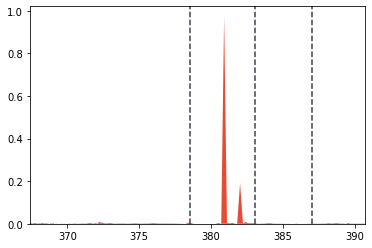

In [ ]:
plt.stackplot(depth_CP,df2[1],colors =['#E64B35FF'])
plt.xlim(xmin = 367.4)
plt.xlim(xmax = 390.71)
plt.axvline(x=378.5,color='#3C4048',linestyle='dashed')
plt.axvline(x=383.03,color='#3C4048',linestyle='dashed')
plt.axvline(x=387,color='#3C4048',linestyle='dashed')
plt.savefig("1.pdf", format='pdf', dpi=1000, bbox_inches='tight')

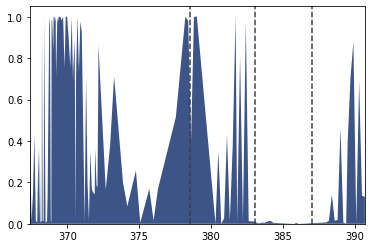

In [ ]:
plt.stackplot(depth_CP,df2[0],colors =['#3C5488FF'])
plt.xlim(xmin = 367.4)
plt.xlim(xmax = 390.71)
plt.axvline(x=378.5,color='#3C4048',linestyle='dashed')
plt.axvline(x=383.03,color='#3C4048',linestyle='dashed')
plt.axvline(x=387,color='#3C4048',linestyle='dashed')
plt.savefig("0.pdf", format='pdf', dpi=1000, bbox_inches='tight')

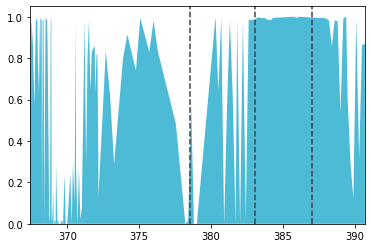

In [ ]:
plt.stackplot(depth_CP,df2[2],colors =['#4DBBD5FF'])
plt.xlim(xmin = 367.4)
plt.xlim(xmax = 390.71)
plt.axvline(x=378.5,color='#3C4048',linestyle='dashed')
plt.axvline(x=383.03,color='#3C4048',linestyle='dashed')
plt.axvline(x=387,color='#3C4048',linestyle='dashed')
plt.savefig("2.pdf", format='pdf', dpi=1000, bbox_inches='tight')